# Analyze uncertainty for CD16-Mono (Loop 3)

Loads the optimized solutions, filters them, and plots histograms/comparisons for the CD16Mono and CD14Mono clusters.

In [1]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [2]:
# Cell type fractions
celltype_fraction = {
    "CD16Mono": 0.01,
    "CD14Mono": 0.01
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

columns_of_interest_l3 =  columns_of_interest + ["il7_[ng_ml]",
                                                 "mcsf_[ng_ml]",
                                                 "ly_cocktail_[ul/well]", 
                                                 "loss", 
                                                 "target_ct_loss_std",
                                                 "target_ct_loss_mean",
                                                 "ct_prop_total_variance"]

## Load solutions 

In [3]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [4]:
# Read annotation files
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l3 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

# Read boundc files
ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l3 = yaml.safe_load(fb)
ubound_dict_l3, lbound_dict_l3 = annotation_cfg_bound_l3["ubound_dict"],  annotation_cfg_bound_l3["lbound_dict"]

bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds_l3 = {}
for param in lbound_dict_l3:
    bounds_l3[param] = (lbound_dict_l3[param], ubound_dict_l3[param])

### Collect optimized samples 

In [5]:
path_to_results_loop2p5 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop2p5_replicate")
path_to_results_loop3 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop3_replicate")

paths_loop2p5 = os.listdir(path_to_results_loop2p5)
paths_loop3 = os.listdir(path_to_results_loop3)

In [8]:
cell_types = ["CD14Mono", "CD16Mono"]

raw_solutions_loop2p5 = load_pure_cell_type_solutions(
    path_to_results_loop2p5,
    paths_loop2p5,
    cell_types,
    load_uncertainties=False
)

raw_solutions_loop3 = load_pure_cell_type_solutions(
    path_to_results_loop3,
    paths_loop3,
    cell_types,
    load_uncertainties=True
)

100%|██████████| 6/6 [00:50<00:00,  8.48s/it]


In [9]:
raw_solutions_loop2p5 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop2p5.items()
}

raw_solutions_loop3 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop3.items()
}

# Filter solutions

In [10]:
# Collect filtered and annotated data frames 
filtered_df_l2p5, annotated_df_l2p5 = manual_filtering(
    df_dict=raw_solutions_loop2p5,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
cd16mono_l2p5 = filtered_df_l2p5["CD16Mono"].reset_index()
cd14mono_l2p5 = filtered_df_l2p5['CD14Mono'].reset_index()

# Collect filtered and annotated data frames 
filtered_df_l3, annotated_df_l3 = manual_filtering(
    df_dict=raw_solutions_loop3,
    bounds=bounds_l3,
    columns_to_keep=columns_of_interest_l3, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l3,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
cd16mono_l3 = filtered_df_l3["CD16Mono"].reset_index()
cd14mono_l3 = filtered_df_l3['CD14Mono'].reset_index()

## Plot histograms

**cd16Mono**

In [11]:
plot_cd16mono = {"Loop": ["Loop 2" for _ in range(len(cd16mono_l2p5))] + ["Loop 3" for _ in range(len(cd16mono_l3))],
                 "Proportion": np.concatenate([cd16mono_l2p5["CD16Mono_prop"], cd16mono_l3["CD16Mono_prop"]])}
plot_cd16mono = pd.DataFrame(plot_cd16mono)

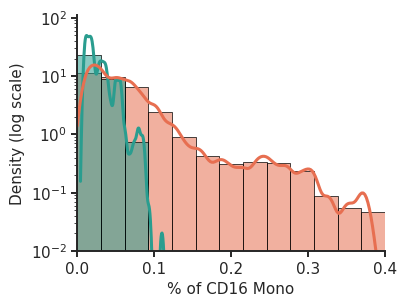

In [12]:
# --- Data (same as before) ---
plot_cd16mono = {
    "Loop": ["Loop 2" for _ in range(len(cd16mono_l2p5))] + ["Loop 3" for _ in range(len(cd16mono_l3))],
    "Proportion": np.concatenate([cd16mono_l2p5["CD16Mono_prop"], cd16mono_l3["CD16Mono_prop"]])
}
plot_cd16mono = pd.DataFrame(plot_cd16mono)
# --- Style ---
sns.set_style("ticks")
plt.rcParams["font.size"] = 11
palette = {"Loop 2": "#2a9d8f", "Loop 3": "#e76f51"}
line_palette = {"Loop 2": "#2a9d8f", "Loop 3": "#e76f51"}
fig, ax = plt.subplots(figsize=(4.2, 3.2))
# Wide, chunky bins (like the reference) instead of seaborn's auto-binning
binwidth = 0.03
xmax = 0.4
sns.histplot(
    plot_cd16mono, x="Proportion", hue="Loop",
    stat="density", common_norm=False,
    binwidth=binwidth, binrange=(0, xmax),
    palette=palette, alpha=0.55, edgecolor="black", linewidth=0.5,
    element="bars", multiple="layer", ax=ax, legend=True
)
# KDE line overlay per group, drawn on top in matching colors
for loop_name, color in line_palette.items():
    subset = plot_cd16mono.loc[plot_cd16mono["Loop"] == loop_name, "Proportion"]
    sns.kdeplot(subset, ax=ax, color=color, linewidth=2.2, clip=(0, xmax), bw_adjust=0.8)
ax.set_xlabel("% of CD16 Mono")
ax.set_ylabel("Density (log scale)")
ax.set_xlim(0, xmax)
# --- Log scale y-axis ---
ax.set_yscale("log")
ax.set_ylim(bottom=1e-2)  # avoid log(0) issues; adjust floor as needed
# Clean up legend (remove border/title box like reference)
handles, labels = ax.get_legend_handles_labels()
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.legend(handles, labels, frameon=False, loc="upper right", fontsize=9)
sns.despine(ax=ax)
for spine in ax.spines.values():
    spine.set_linewidth(1.4)
ax.tick_params(width=1.4, length=4)
plt.tight_layout()
plt.savefig("plots/cd16mono_loop_comparison.svg", dpi=300, bbox_inches="tight")
plt.savefig("plots/cd16mono_loop_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**cd14Mono**

In [13]:
plot_cd14mono = {"Loop": ["Loop 2" for _ in range(len(cd14mono_l2p5))] + ["Loop 3" for _ in range(len(cd14mono_l3))],
                 "Proportion": np.concatenate([cd14mono_l2p5["CD14Mono_prop"], cd14mono_l3["CD14Mono_prop"]])}
plot_cd14mono = pd.DataFrame(plot_cd14mono)

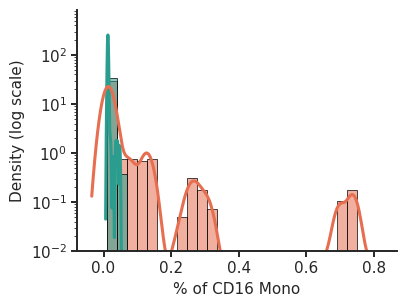

In [19]:
# --- Data (same as before) ---
plot_cd14mono = {
    "Loop": ["Loop 2" for _ in range(len(cd14mono_l2p5))] + ["Loop 3" for _ in range(len(cd14mono_l3))],
    "Proportion": np.concatenate([cd14mono_l2p5["CD14Mono_prop"], cd14mono_l3["CD14Mono_prop"]])
}
plot_cd14mono = pd.DataFrame(plot_cd14mono)
# --- Style ---
sns.set_style("ticks")
plt.rcParams["font.size"] = 11
palette = {"Loop 2": "#2a9d8f", "Loop 3": "#e76f51"}
line_palette = {"Loop 2": "#2a9d8f", "Loop 3": "#e76f51"}
fig, ax = plt.subplots(figsize=(4.2, 3.2))
# Wide, chunky bins (like the reference) instead of seaborn's auto-binning
binwidth = 0.03
# xmax = 0.4
sns.histplot(
    plot_cd14mono, x="Proportion", hue="Loop",
    stat="density", common_norm=False,
    binwidth=binwidth, 
    palette=palette, alpha=0.55, edgecolor="black", linewidth=0.5,
    element="bars", multiple="layer", ax=ax, legend=True
)
# KDE line overlay per group, drawn on top in matching colors
for loop_name, color in line_palette.items():
    subset = plot_cd14mono.loc[plot_cd14mono["Loop"] == loop_name, "Proportion"]
    sns.kdeplot(subset, ax=ax, color=color, linewidth=2.2)
ax.set_xlabel("% of CD16 Mono")
ax.set_ylabel("Density (log scale)")
# ax.set_xlim(0, xmax)

# --- Log scale y-axis ---
ax.set_yscale("log")
ax.set_ylim(bottom=1e-2)  # avoid log(0) issues; adjust floor as needed

# Clean up legend (remove border/title box like reference)
handles, labels = ax.get_legend_handles_labels()
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.legend(handles, labels, frameon=False, loc="upper right", fontsize=9)
sns.despine(ax=ax)
for spine in ax.spines.values():
    spine.set_linewidth(1.4)
ax.tick_params(width=1.4, length=4)
plt.tight_layout()
plt.savefig("plots/cd14mono_loop_comparison.svg", dpi=300, bbox_inches="tight")
plt.savefig("plots/cd14mono_loop_comparison.png", dpi=300, bbox_inches="tight")
plt.show()